**Tutorial Code by Amirhossein Ahrari YouTube:** https://www.youtube.com/@amirhosseinahrarigee

**Tutorial Video: PySTAC Tutorial-7: Sentinel-2 NDVI GapFilling using SG Filter in Python**

This code is part of a tutorial series on python eo programming techniques
presented on the Amirhossein Ahrari YouTube channel. You are free to use and modify
this code for academic and non-academic purposes. Don't forget to subscribe to
the Amirhossein Ahrari channel and follow the videos to support the instructor.

In [1]:
!pip install -q pystac-client stackstac

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.5 MB/s eta 0:00:00


In [2]:
from pystac_client import Client

In [3]:
catalog = Client.open(
    'https://earth-search.aws.element84.com/v1'
)

In [4]:
for collection in catalog.get_collections():
  print(collection.id)

sentinel-2-pre-c1-l2a
cop-dem-glo-30
naip
cop-dem-glo-90
landsat-c2-l2
sentinel-2-l2a
sentinel-2-l1c
sentinel-2-c1-l2a
sentinel-1-grd


In [5]:
roi = [45.731184, 36.905119, 45.779577, 36.942738]

In [6]:
search = catalog.search(
    collections = ['sentinel-2-c1-l2a'],
    bbox = roi,
    datetime = '2023/2025'
)

In [8]:
items =  search.item_collection()

/usr/local/lib/python3.13/dist-packages/pystac/extensions/storage.py:724: UserWarning: Could not parse bucket/account from href. The following assets were not migrated: ['red', 'green', 'blue', 'visual', 'nir', 'swir22', 'rededge2', 'rededge3', 'rededge1', 'swir16', 'wvp', 'nir08', 'scl', 'aot', 'coastal', 'nir09', 'cloud', 'snow', 'preview', 'granule_metadata', 'tileinfo_metadata', 'product_metadata', 'thumbnail']
  warnings.warn(


In [9]:
len(items)

496

In [10]:
items[0]

<Item id=S2B_T38SNF_20251231T075612_L2A>

In [11]:
items[0].assets.keys()

dict_keys(['red', 'green', 'blue', 'visual', 'nir', 'swir22', 'rededge2', 'rededge3', 'rededge1', 'swir16', 'wvp', 'nir08', 'scl', 'aot', 'coastal', 'nir09', 'cloud', 'snow', 'preview', 'granule_metadata', 'tileinfo_metadata', 'product_metadata', 'thumbnail'])

In [12]:
import stackstac

In [13]:
ds = stackstac.stack(
    items,
    assets = ['red','nir','scl'],
    bounds_latlon = roi,
    epsg = 3857,
    resolution = 10
)

In [14]:
ds

<xarray.DataArray 'stackstac-39886a2d0f34551f2b9605710eb15623' (time: 496,
                                                                band: 3,
                                                                y: 525, x: 539)> Size: 3GB
dask.array<fetch_raster_window, shape=(496, 3, 525, 539), dtype=float64, chunksize=(1, 1, 525, 539), chunktype=numpy.ndarray>
Coordinates: (12/55)
  * time                                     (time) datetime64[ns] 4kB 2023-0...
  * band                                     (band) <U3 36B 'red' 'nir' 'scl'
  * y                                        (y) float64 4kB 4.431e+06 ... 4....
  * x                                        (x) float64 4kB 5.091e+06 ... 5....
    id                                       (time) <U30 60kB 'S2A_T38SNF_202...
    proj:code                                <U10 40B 'EPSG:32638'
    ...                                       ...
    raster:bands                             (band) object 24B {'nodata': 0, ...
    gsd                                      (band) int64 24B 10 10 20
    common_name                              (band) object 24B 'red' 'nir' None
    center_wavelength                        (band) object 24B 0.665 0.842 None
    full_width_half_max                      (band) object 24B 0.038 0.145 None
    epsg                                     int64 8B 3857
Attributes:
    spec:        RasterSpec(epsg=3857, bounds=(5090770, 4425880, 5096160, 443...
    crs:         epsg:3857
    transform:   | 10.00, 0.00, 5090770.00|\n| 0.00,-10.00, 4431130.00|\n| 0....
    resolution:  10

In [15]:
import xarray as xr

In [19]:
ds_clean = (
    ds.to_dataset('band')
    .drop_dims('band')
    .reset_coords(drop = True)
    .drop_attrs()

)

In [20]:
cloud_pixels = ds_clean.scl.isin([3,8,9,10]).astype(int)
ds_mask = ds_clean[['nir','red']].where(cloud_pixels == 0)

In [21]:
nir = ds_mask['nir']
red = ds_mask['red']
ndvi = ((nir - red)/(nir + red)).rename('ndvi')

In [22]:
ndvi_weekly = ndvi.resample(time = 'W').max('time')

In [23]:
from dask.diagnostics import ProgressBar

In [25]:
import warnings
warnings.filterwarnings('ignore', category = RuntimeWarning)
import logging
logging.getLogger().setLevel(logging.ERROR)

In [26]:
with ProgressBar():
  ndwi_weekly = ndvi_weekly.compute()

[########################################] | 100% Completed | 543.37 s


In [27]:
ndvi_ds = ndwi_weekly.copy()

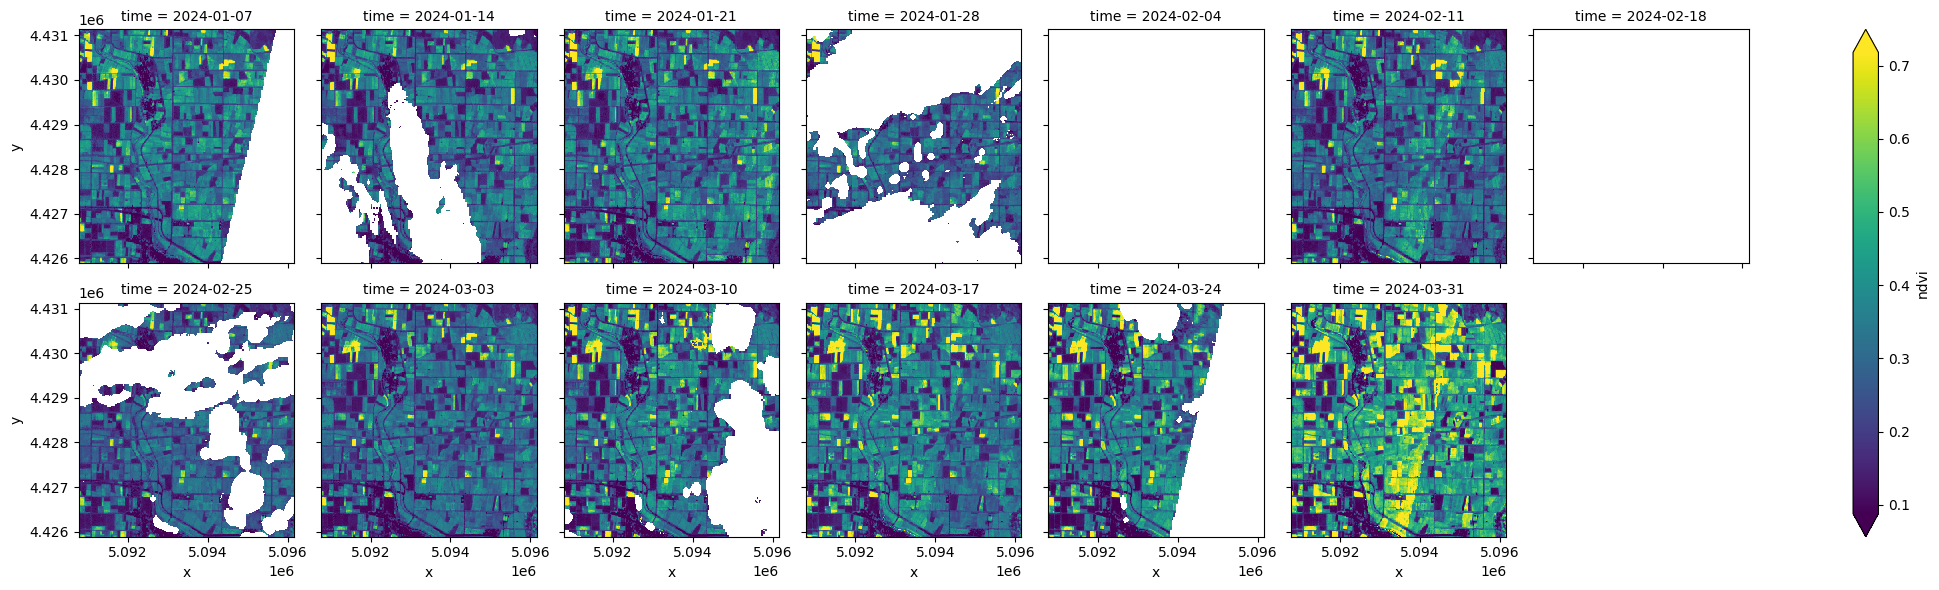

In [29]:
ndvi_ds.sel(time = slice('2024-01','2024-3')).plot(
    robust =True, col = 'time', col_wrap = 7
)

In [30]:
ndvi_int = ndvi_ds.interpolate_na(dim = 'time', method = 'linear', fill_value = 'extrapolate')
ndvi_int = ndvi_int.ffill('time').bfill('time')

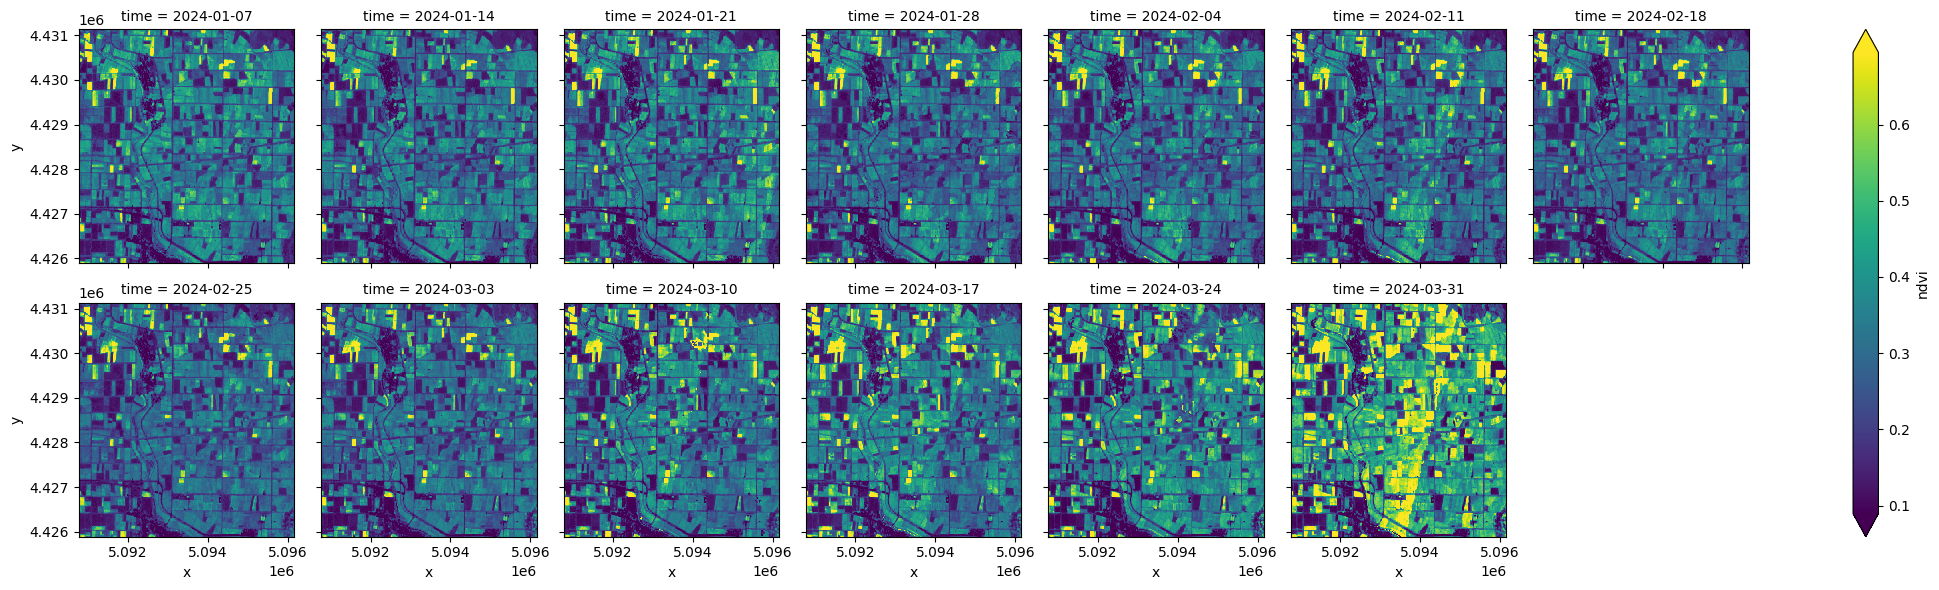

In [31]:
ndvi_int.sel(time = slice('2024-01','2024-03')).plot(
    robust =True, col = 'time', col_wrap = 7
)

In [32]:
from scipy.signal import savgol_filter

In [34]:
ndvi_trans = ndvi_int.transpose('x','y','time')

In [37]:
ndvi_val = ndvi_trans.values

In [38]:
ndvi_val.shape

(539, 525, 158)

In [39]:
ndvi_filter = savgol_filter(
    ndvi_val,
    window_length = 5,
    polyorder = 2,
    axis = -1,
    mode = 'interp'
)

In [41]:
import xarray as xr

In [42]:
ndvi_result = xr.DataArray(
    ndvi_filter,
    dims = ndvi_trans.dims,
    coords = ndvi_trans.coords
)

In [43]:
ndvi_result

<xarray.DataArray (x: 539, y: 525, time: 158)> Size: 358MB
array([[[ 0.35661468,  0.33111954,  0.31206067, ...,  0.41139154,
          0.27780274,  0.08214609],
        [ 0.34744826,  0.32960083,  0.31525735, ...,  0.42148671,
          0.28942804,  0.09597823],
        [ 0.34744826,  0.32960083,  0.31525735, ...,  0.42148671,
          0.28942804,  0.09597823],
        ...,
        [ 0.29604796,  0.26205568,  0.24695001, ...,  0.36174586,
          0.33929281,  0.30854392],
        [ 0.29604796,  0.26205568,  0.24695001, ...,  0.36174586,
          0.33929281,  0.30854392],
        [ 0.27908799,  0.26608224,  0.26146171, ...,  0.38088035,
          0.37963741,  0.38445951]],

       [[ 0.32449532,  0.30834194,  0.29719508, ...,  0.41403314,
          0.28322452,  0.08704728],
        [ 0.3340713 ,  0.31384493,  0.29979784, ...,  0.43323559,
          0.29968503,  0.0904798 ],
        [ 0.3340713 ,  0.31384493,  0.29979784, ...,  0.43323559,
          0.29968503,  0.0904798 ],
...
        [ 0.31907615,  0.30826208,  0.30318836, ...,  0.15835889,
          0.14308961,  0.12782033],
        [ 0.2683201 ,  0.27762383,  0.28095454, ...,  0.19933748,
          0.21111125,  0.22288502],
        [ 0.29438561,  0.28202423,  0.27361856, ...,  0.18583866,
          0.17477466,  0.16371067]],

       [[ 0.13136946,  0.13381145,  0.13306133, ...,  0.04000561,
          0.00441314, -0.03117934],
        [ 0.13163476,  0.13709624,  0.13806179, ..., -0.00816695,
         -0.0696211 , -0.13107525],
        [ 0.15268772,  0.13909638,  0.13863572, ...,  0.01616517,
         -0.04049775, -0.09716067],
        ...,
        [ 0.32638458,  0.30853934,  0.29711218, ...,  0.13440645,
          0.11314664,  0.09188684],
        [ 0.32405712,  0.30758994,  0.29944886, ...,  0.21832671,
          0.23722458,  0.25612245],
        [ 0.3154897 ,  0.29388641,  0.28269115, ...,  0.15596463,
          0.12695816,  0.09795169]]])
Coordinates:
  * x        (x) float64 4kB 5.091e+06 5.091e+06 ... 5.096e+06 5.096e+06
  * y        (y) float64 4kB 4.431e+06 4.431e+06 ... 4.426e+06 4.426e+06
  * time     (time) datetime64[ns] 1kB 2023-01-01 2023-01-08 ... 2026-01-04

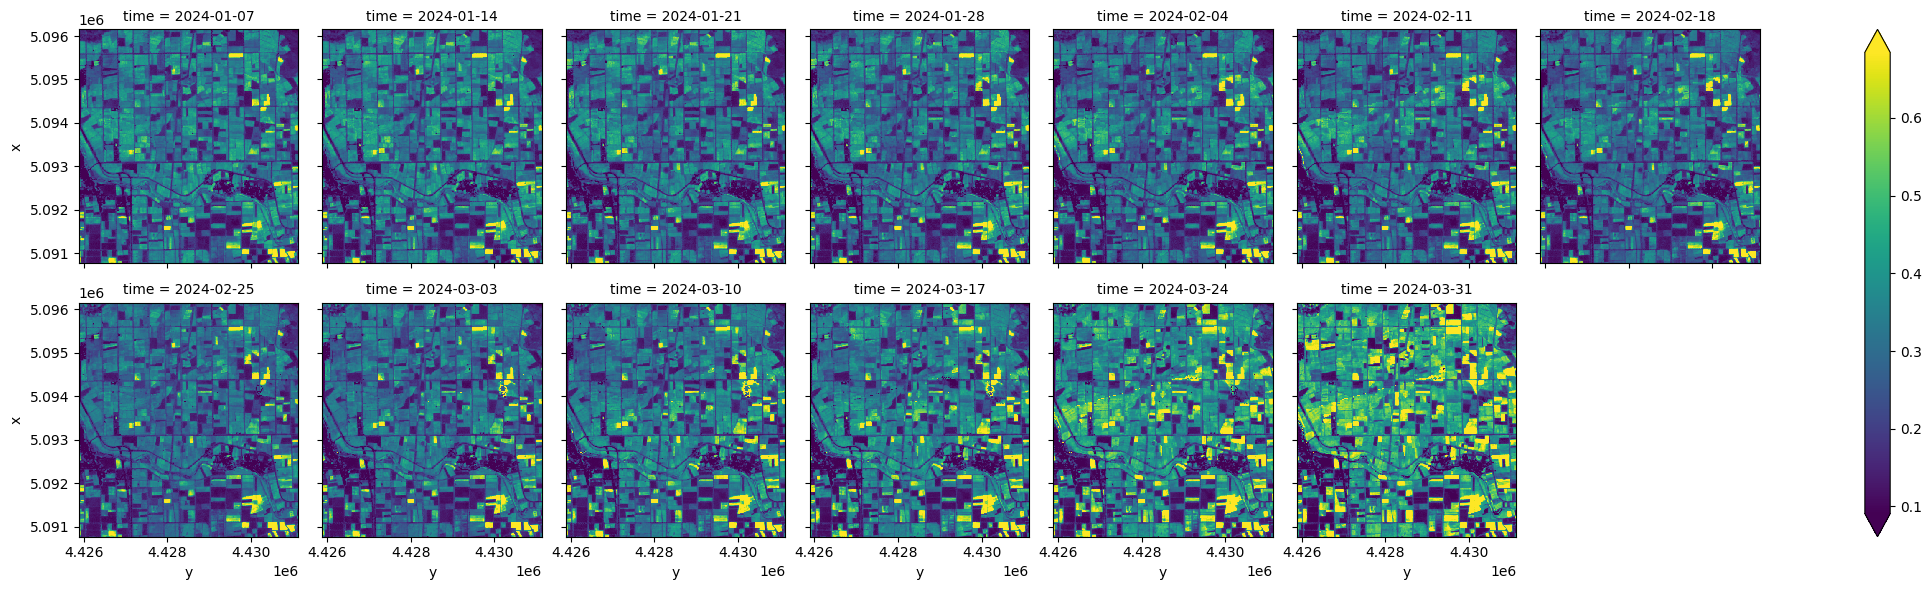

In [44]:
ndvi_result.sel(time = slice('2024-01','2024-03')).plot(
    robust = True, col = 'time', col_wrap = 7
)

In [45]:
ndvi_before = ndvi_ds.median(dim = ['x','y'])
ndvi_after = ndvi_result.median(dim = ['x','y'])

In [46]:
import matplotlib.pyplot as plt

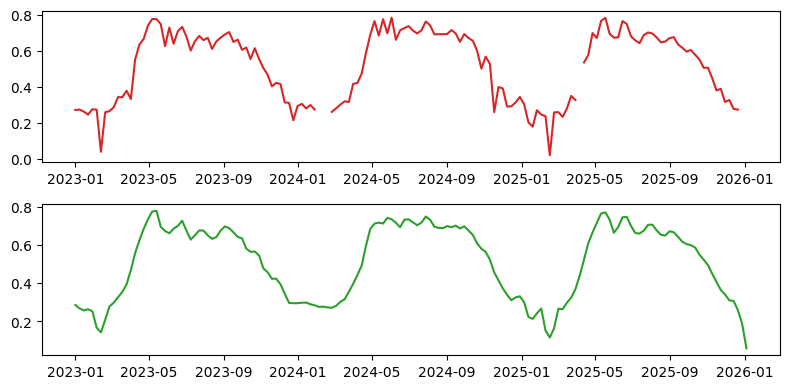

In [51]:
fig, ax = plt.subplots(2,1, figsize = (8,4))

ax[0].plot(ndvi_before.time, ndvi_before, color = 'tab:red')
ax[1].plot(ndvi_after.time, ndvi_after, color = 'tab:green')

plt.tight_layout()